# Week 3 — What Influences Urban Tree Cover?
## Part 3 of 3: Mapping the Predictors

**Conscientiâ Data Science Newsletter**

Notebook 2 found which predictors correlate with tree cover and grouped cities into archetypal clusters. This notebook puts those patterns on a map to check for obvious regional structure — e.g., does the "dense & impervious" cluster skew Northeast, or is it scattered nationally?

Purely visual/descriptive — same "no modeling" spirit as Notebook 2.


## 0. Setup

In [1]:
!pip install -q geopandas contextily

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as cx

NATURAL_PALETTE = ["#2E5339", "#6B8E4E", "#A9BA9D", "#C9A66B", "#8C6239", "#4A3728"]
NATURAL_CMAP = mcolors.LinearSegmentedColormap.from_list("natural", ["#C9A66B", "#6B8E4E", "#2E5339"])


## 1. Load clustered predictor table

In [2]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

CSV_NAME = "week3_city_predictors_clustered.csv"

if IN_COLAB:
    uploaded = files.upload()
    CSV_NAME = list(uploaded.keys())[0]

df = pd.read_csv(CSV_NAME)

gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["long"], df["lat"]), crs="EPSG:4326"
)
gdf_web = gdf.to_crs(epsg=3857)  # Web Mercator, needed for contextily basemaps
gdf_web.head()


Saving week3_city_predictors_clustered.csv to week3_city_predictors_clustered.csv


,city,state,region,population,lat,long,tree_city_usa,ref_number_trees,ref_number_species,ref_effective_species,...,pct_water,pct_parkland,pct_impervious_proxy,population_density_per_km2,trees_per_km2,trees_per_1000_pop,cluster,pca1,pca2,geometry
0,Albuquerque,New Mexico,West,556495,35.085334,-106.605553,yes,2533,80,34.308079,...,0.008644,0.101283,0.428055,1073.460579,4.886074,4.551703,4,-0.594238,2.146731,POINT (-11867275.92 4175483.695)
1,Anaheim,California,West,345012,33.835293,-117.914504,yes,79651,291,52.411599,...,0.028259,0.048618,0.433079,2620.057374,604.878062,230.864434,2,0.874090,-0.441781,POINT (-13126182.498 4006707.31)
2,Arlington,Texas,South,379577,32.735687,-97.108066,yes,14827,104,31.429879,...,0.044521,0.035914,0.537761,1469.783272,57.412532,39.061903,1,-0.455464,-1.074843,POINT (-10810020.415 3860273.156)
3,Atlanta,Georgia,South,447841,33.748995,-84.387982,yes,41307,284,57.090891,...,0.007924,0.037766,0.694056,1271.349084,117.263977,92.235860,1,-1.397195,-1.151342,POINT (-9394027.23 3995147.832)
4,Aurora (CO),Colorado,West,345803,39.729432,-104.831919,yes,57658,119,21.535282,...,0.013026,0.036362,0.303586,828.961278,138.218146,166.736552,0,-1.620550,1.284662,POINT (-11669835.898 4826701.609)


## 2. Continental US point maps, one panel per predictor

Hawaii (Honolulu) is excluded from these maps for basemap framing — it's included in all the numeric analysis in Notebook 2.

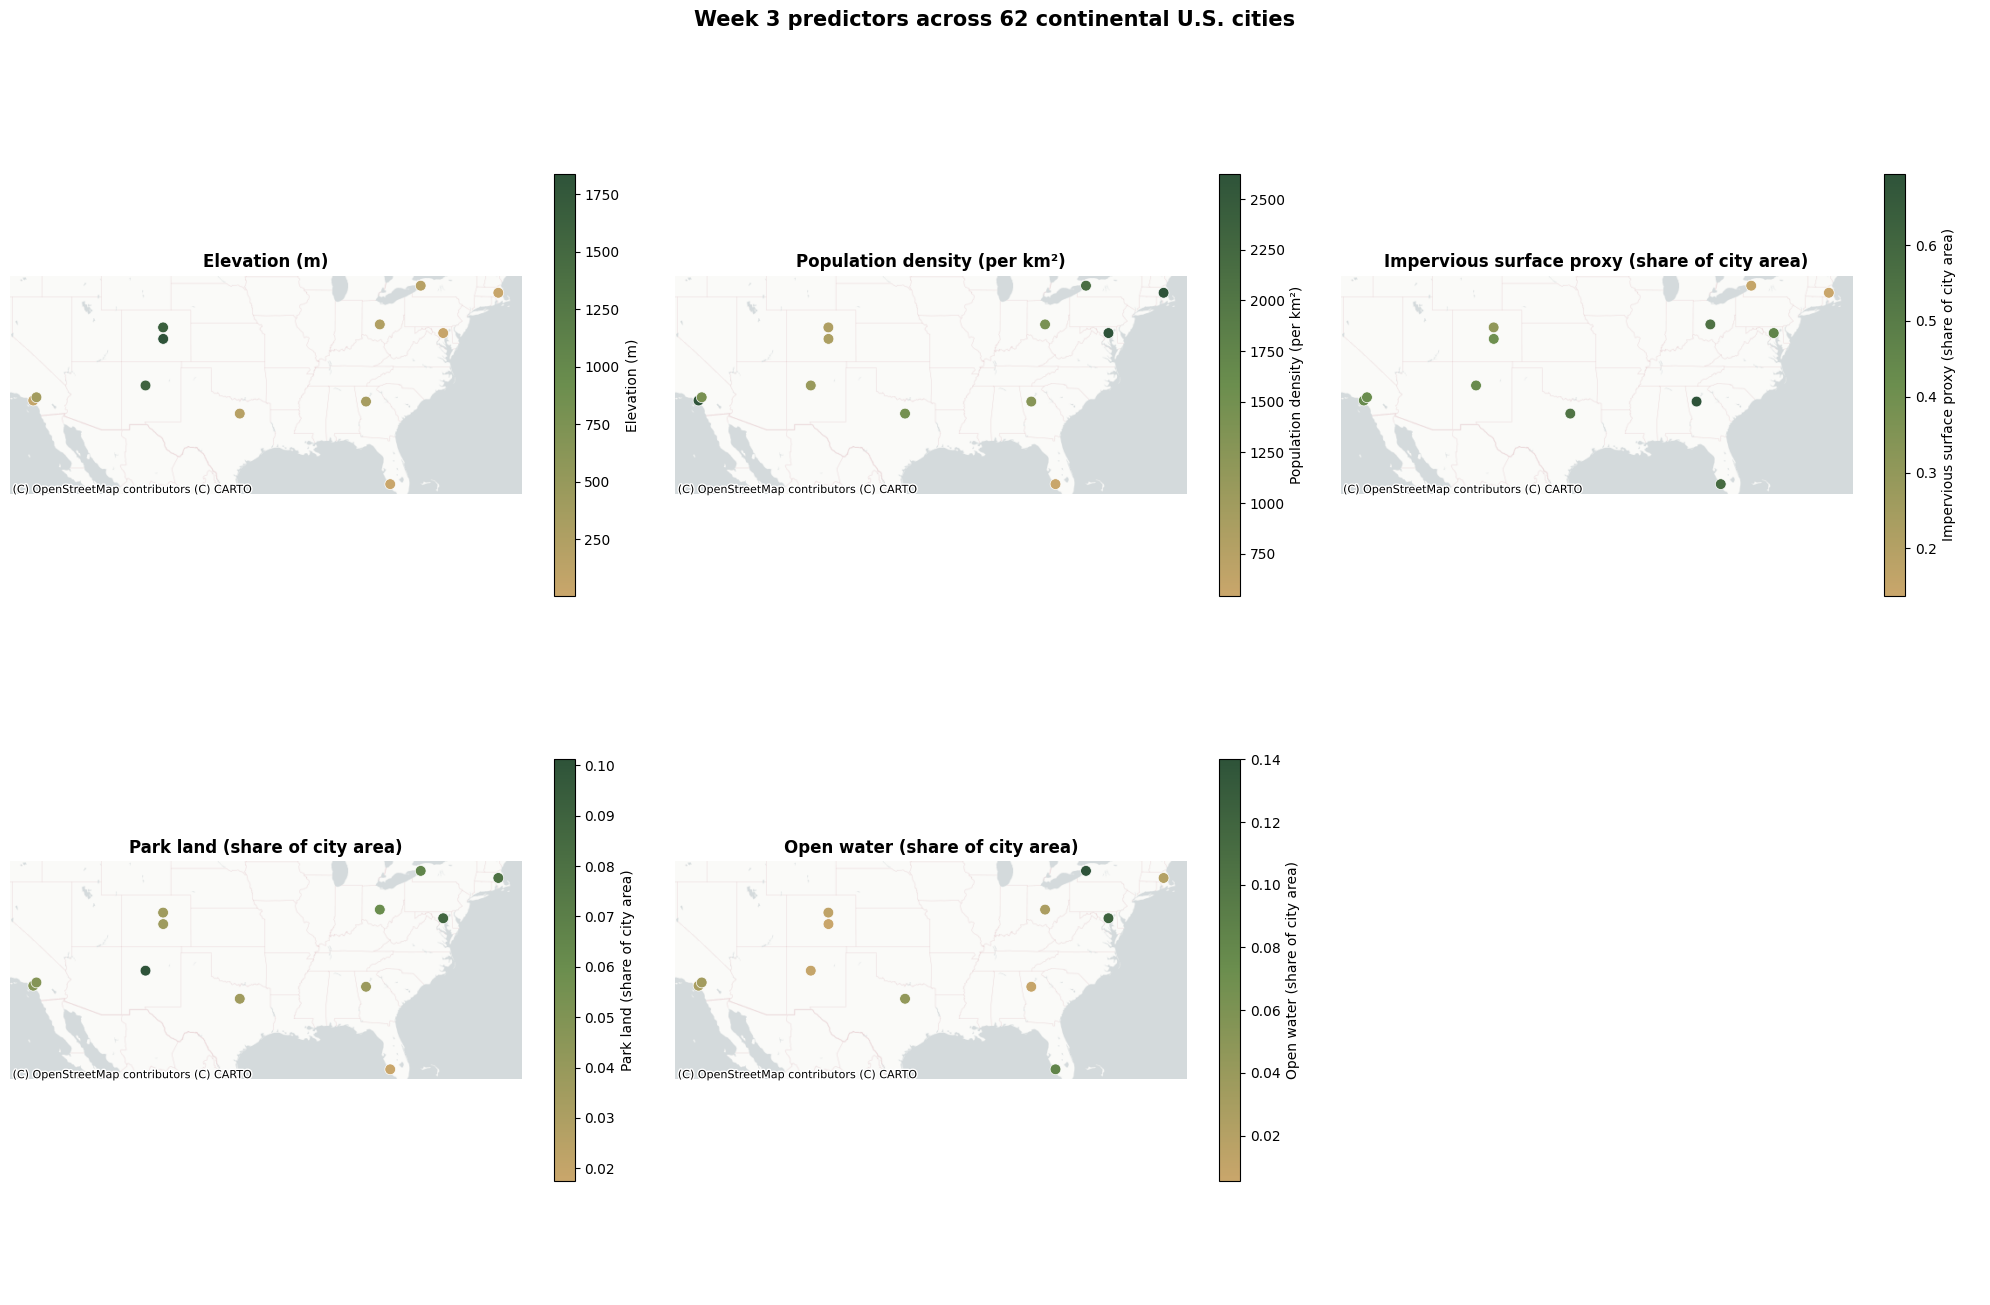

In [3]:
conus = gdf_web[gdf_web["state"] != "Hawaii"].copy()

PREDICTORS = [
    "elevation_m",
    "population_density_per_km2",
    "pct_impervious_proxy",
    "pct_parkland",
    "pct_water",
]
TITLES = {
    "elevation_m": "Elevation (m)",
    "population_density_per_km2": "Population density (per km²)",
    "pct_impervious_proxy": "Impervious surface proxy (share of city area)",
    "pct_parkland": "Park land (share of city area)",
    "pct_water": "Open water (share of city area)",
}

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
for ax, col in zip(axes.flat, PREDICTORS):
    conus.plot(
        ax=ax, column=col, cmap=NATURAL_CMAP, markersize=60,
        edgecolor="white", linewidth=0.5, legend=True,
        legend_kwds={"shrink": 0.65, "label": TITLES[col]},
    )
    cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, zoom=4)
    ax.set_title(TITLES[col], fontsize=12, fontweight="bold")
    ax.set_axis_off()

axes.flat[-1].set_axis_off()
plt.suptitle("Week 3 predictors across 62 continental U.S. cities", fontsize=15, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig("week3_predictor_maps.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Cluster map

Where do the archetypes from Notebook 2 fall geographically?

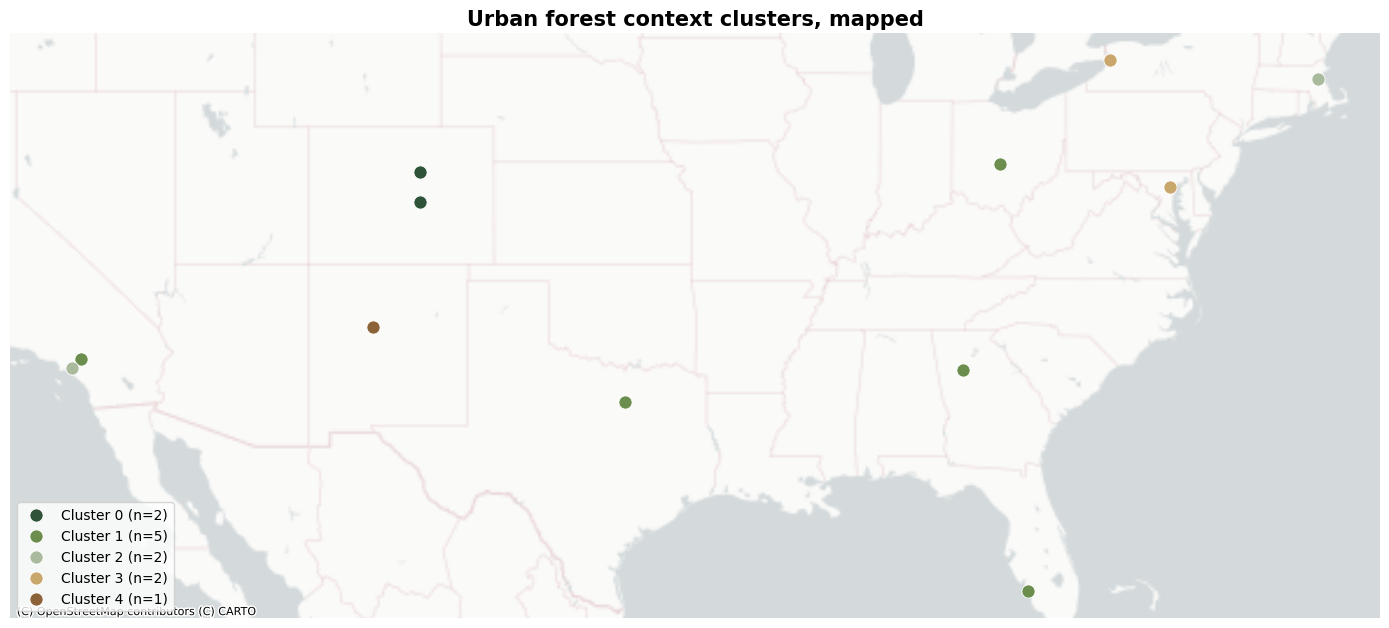

In [4]:
fig, ax = plt.subplots(figsize=(14, 9))

clusters = sorted(conus["cluster"].dropna().unique())
for i, cluster_id in enumerate(clusters):
    sub = conus[conus["cluster"] == cluster_id]
    sub.plot(
        ax=ax, color=NATURAL_PALETTE[i % len(NATURAL_PALETTE)], markersize=90,
        edgecolor="white", linewidth=0.6, label=f"Cluster {int(cluster_id)} (n={len(sub)})",
    )

cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, zoom=4)
ax.set_axis_off()
ax.set_title("Urban forest context clusters, mapped", fontsize=15, fontweight="bold")
ax.legend(loc="lower left", fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig("week3_cluster_map.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Regional cluster composition

A quick crosstab: does cluster membership skew by Census region?

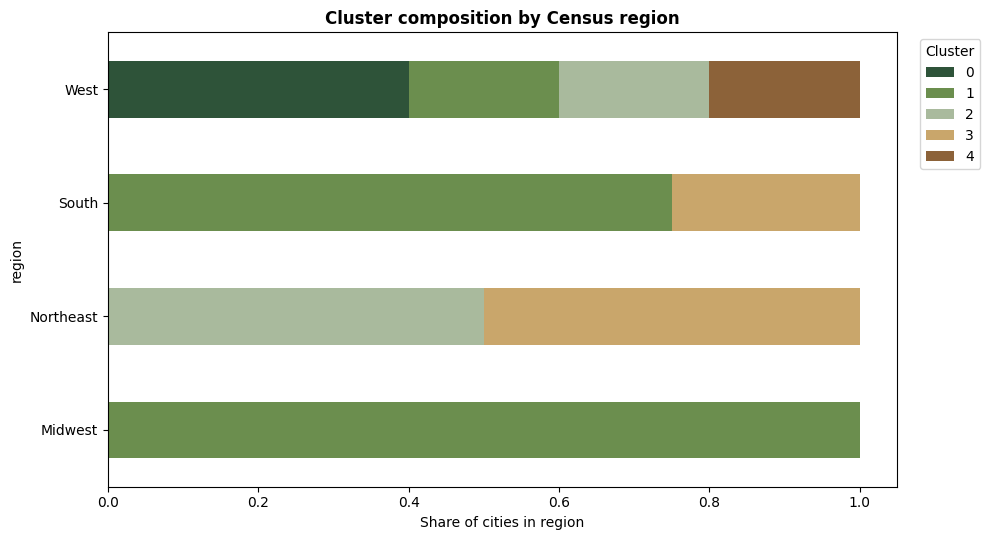

cluster,0,1,2,3,4
region,,,,,
Midwest,0,1,0,0,0
Northeast,0,0,1,1,0
South,0,3,0,1,0
West,2,1,1,0,1


In [5]:
region_cluster = pd.crosstab(df["region"], df["cluster"])
region_cluster_pct = region_cluster.div(region_cluster.sum(axis=1), axis=0).round(2)

fig, ax = plt.subplots(figsize=(10, 5.5))
region_cluster_pct.plot(
    kind="barh", stacked=True, ax=ax,
    color=[NATURAL_PALETTE[i % len(NATURAL_PALETTE)] for i in range(region_cluster_pct.shape[1])],
)
ax.set_xlabel("Share of cities in region")
ax.set_title("Cluster composition by Census region", fontweight="bold")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("week3_region_cluster_composition.png", dpi=150, bbox_inches="tight")
plt.show()

region_cluster


## Wrap-up

This closes out Week 3. Recap for the newsletter write-up:

1. **Notebook 1** merged elevation, population density, impervious-surface proxy, park land, and open water onto the 63-city tree census reference table — all from free, no-auth public sources (OSM via `osmnx`, Open-Elevation/Open-Meteo).
2. **Notebook 2** found the correlation structure between those predictors and tree-cover outcomes (density, per-capita counts, effective species diversity, native-species share), then grouped cities into unsupervised "urban forest context" clusters.
3. **Notebook 3** (this one) mapped everything to check for geographic/regional structure in the patterns.

**What we deliberately didn't do:** fit a predictive model. Everything here is descriptive — correlations, a bivariate relevance ranking, and unsupervised clustering. If Week 4 wants to build an actual predictive model of tree cover from these features (with the honest reporting of limitations this newsletter is known for), this predictor table is ready to be a training set.
